In [1]:
# 5.1 Import Library dan Konfigurasi Path
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Path folder evaluasi (sesuai hasil diagnostik)
EVAL_DIR = '../outputs/evaluation'

# Validasi folder
if not os.path.exists(EVAL_DIR):
    raise FileNotFoundError(f"Folder {EVAL_DIR} tidak ditemukan. Periksa lokasi notebook.")

# Ambil semua file CSV evaluasi (kecuali ground_truth)
csv_files = [f for f in os.listdir(EVAL_DIR) 
             if f.startswith('evaluation_metrics_') and f.endswith('.csv')]
csv_files.sort()

if len(csv_files) < 7:
    print(f"Peringatan: Hanya ditemukan {len(csv_files)} file evaluasi. Pastikan ke-7 skenario sudah dijalankan.")
else:
    print(f"Berhasil ditemukan {len(csv_files)} file evaluasi.")

Berhasil ditemukan 7 file evaluasi.


In [2]:
# 5.2 Load, Gabungkan, dan Urutkan Sesuai Urutan Logis Penelitian
dfs = []

# 1. Daftar semua metrik yang ingin kita tampilkan
all_metrics = [
    # Klasifikasi
    'Accuracy', 'Precision (M)', 'Recall (M)', 'F1-Score (M)',
    # Continuous / Regresi
    'Pearson-r', 'Spearman-rho', 'R-Squared', 'RMSE', 'MAE'
]

# 2. Mapping Nama File ke Nama Konfigurasi (Diperbarui: Tanpa Ignore -> Tanpa Perlakuan)
filename_map = {
    'evaluation_metrics_RSN_with_Ignore.csv': 'RSN + Ignore Function',
    'evaluation_metrics_RSN_remove_function.csv': 'RSN + Remove Function',
    'evaluation_metrics_RSN_tanpa_perlakuan.csv': 'RSN + Tanpa Perlakuan',
    'evaluation_metrics_SLA_with_Ignore.csv': 'SLA + Ignore Function',
    'evaluation_metrics_SLA_remove_function.csv': 'SLA + Remove Function',
    'evaluation_metrics_SLA_tanpa_perlakuan.csv': 'SLA + Tanpa Perlakuan',
    'evaluation_metrics_VTB.csv': 'VTB (Translation Based)'
}

# 3. Loop untuk membaca file
for filename in csv_files:
    filepath = os.path.join(EVAL_DIR, filename)
    
    try:
        df = pd.read_csv(filepath)
        
        # Ambil kolom metrik yang ada
        cols_to_extract = [col for col in all_metrics if col in df.columns]
        df_subset = df[cols_to_extract].copy()
        
        # FIX: Assign nama konfigurasi berdasarkan nama file
        if filename in filename_map:
            df_subset['Konfigurasi'] = filename_map[filename]
        else:
            df_subset['Konfigurasi'] = filename 
            
        dfs.append(df_subset)
        
    except Exception as e:
        print(f" Gagal memproses {filename}: {e}")

# 4. Gabungkan DataFrame
if dfs:
    df_comparison = pd.concat(dfs, ignore_index=True)

    # 5. Konversi ke numeric
    for col in all_metrics:
        if col in df_comparison.columns:
            df_comparison[col] = pd.to_numeric(df_comparison[col], errors='coerce')

    # 6. Urutan Manual (Diperbarui: Tanpa Ignore -> Tanpa Perlakuan)
    custom_order = [
        'RSN + Ignore Function',
        'RSN + Remove Function',
        'RSN + Tanpa Perlakuan',
        'SLA + Ignore Function',
        'SLA + Remove Function',
        'SLA + Tanpa Perlakuan',
        'VTB (Translation Based)'
    ]

    # Terapkan pengurutan
    df_comparison['Konfigurasi'] = pd.Categorical(
        df_comparison['Konfigurasi'], 
        categories=custom_order, 
        ordered=True
    )
    df_comparison = df_comparison.sort_values('Konfigurasi').reset_index(drop=True)

    # Simpan list kolom metrik yang valid
    metric_cols = [col for col in all_metrics if col in df_comparison.columns]

    print("\n TABEL PERBANDINGAN KINERJA SEMUA SKENARIO")
    display(df_comparison)
else:
    print("Tidak ada data yang berhasil dimuat.")


 TABEL PERBANDINGAN KINERJA SEMUA SKENARIO


,Accuracy,Precision (M),Recall (M),F1-Score (M),Pearson-r,Konfigurasi
0,0.56,0.59,0.54,0.52,0.46,RSN + Ignore Function
1,0.56,0.58,0.53,0.51,0.46,RSN + Remove Function
2,0.58,0.57,0.55,0.54,0.52,RSN + Tanpa Perlakuan
3,0.56,0.59,0.54,0.52,0.46,SLA + Ignore Function
4,0.56,0.58,0.53,0.51,0.46,SLA + Remove Function
5,0.58,0.57,0.55,0.54,0.52,SLA + Tanpa Perlakuan
6,0.54,0.56,0.53,0.54,0.42,VTB (Translation Based)


In [3]:
# 5.3 Simpan Hasil Perbandingan
COMPARE_CSV = os.path.join(EVAL_DIR, 'comparison_all_approaches.csv')
df_comparison.to_csv(COMPARE_CSV, index=False)
print(f"\nHasil perbandingan tersimpan di: {COMPARE_CSV}")


Hasil perbandingan tersimpan di: ../outputs/evaluation\comparison_all_approaches.csv


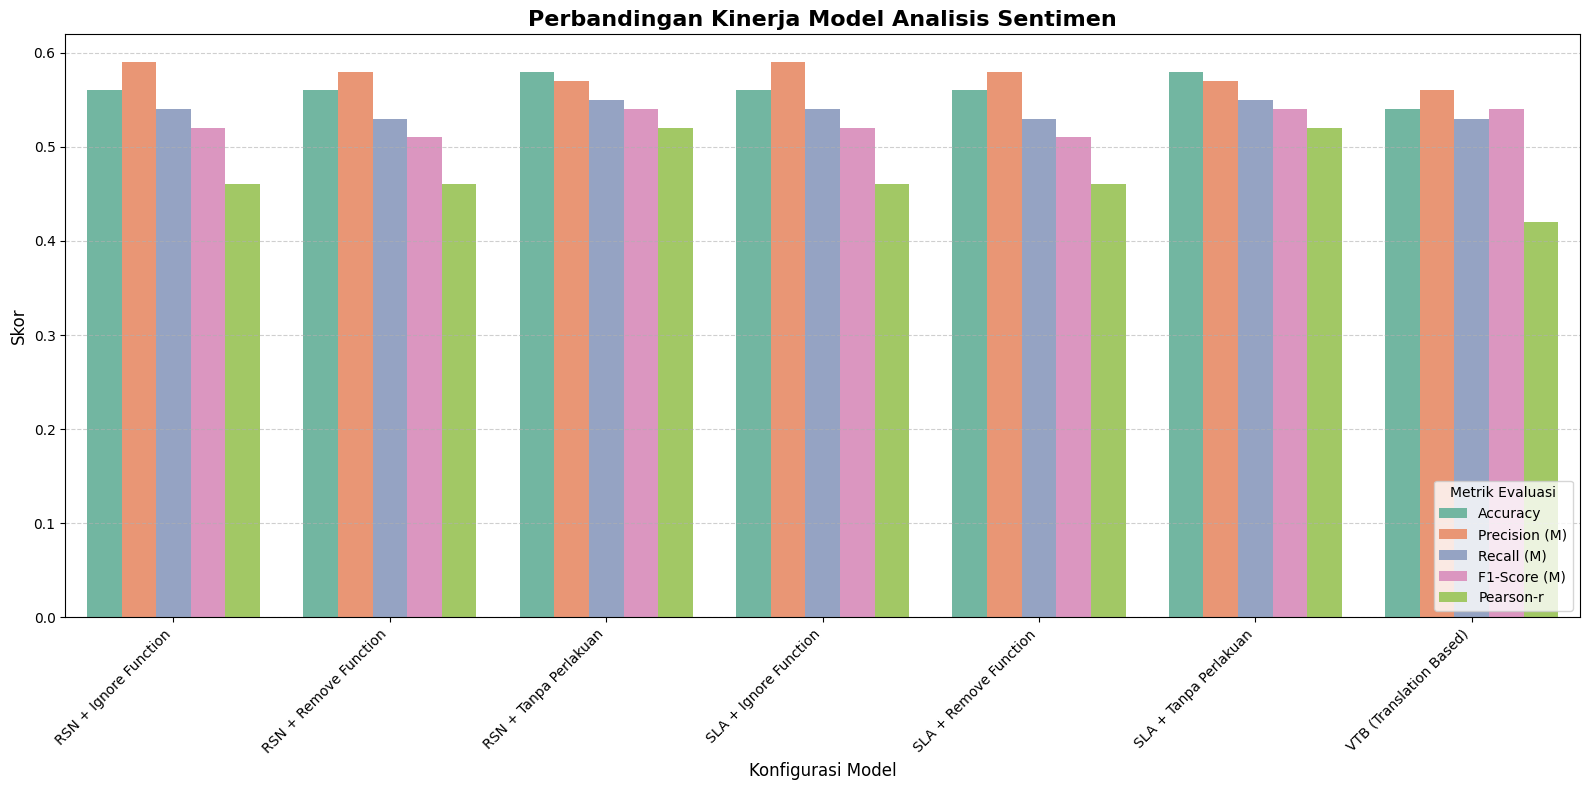


Grafik perbandingan tersimpan di: ../outputs/evaluation\comparison_chart_all_metrics.png


In [4]:
# 5.4 Visualisasi Perbandingan

df_melt = df_comparison.melt(
    id_vars='Konfigurasi',
    value_vars=metric_cols,
    var_name='Metrik',
    value_name='Skor'
)

plt.figure(figsize=(16, 8)) 
sns.barplot(
    data=df_melt,
    x='Konfigurasi',
    y='Skor',
    hue='Metrik',
    palette='Set2',
    errorbar=None
)

plt.title('Perbandingan Kinerja Model Analisis Sentimen', fontsize=16, fontweight='bold')
plt.ylabel('Skor', fontsize=12)
plt.xlabel('Konfigurasi Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrik Evaluasi', loc='lower right', bbox_to_anchor=(1, 0))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

chart_path = os.path.join(EVAL_DIR, 'comparison_chart_all_metrics.png')
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nGrafik perbandingan tersimpan di: {chart_path}")

In [5]:
# 5.5 Identifikasi Skenario Terbaik per Metrik
print("\n SKENARIO TERBAIK PER METRIK:")
print("=" * 70)

for metric in metric_cols:
    best_idx = df_comparison[metric].idxmax()
    best_config = df_comparison.loc[best_idx, 'Konfigurasi']
    best_score = df_comparison.loc[best_idx, metric]
    print(f"  {metric: <20} -> {best_config} ({best_score:.4f})")

print("\n" + "=" * 70)
print("\n CATATAN:")
print("  - Untuk metrik klasifikasi (Accuracy, Precision, Recall, F1): semakin tinggi semakin baik")
print("  - Untuk Pearson-r, Spearman-rho, R-Squared: semakin tinggi semakin baik")
print("  - Untuk RMSE, MAE: semakin rendah semakin baik")


 SKENARIO TERBAIK PER METRIK:
  Accuracy             -> RSN + Tanpa Perlakuan (0.5800)
  Precision (M)        -> RSN + Ignore Function (0.5900)
  Recall (M)           -> RSN + Tanpa Perlakuan (0.5500)
  F1-Score (M)         -> RSN + Tanpa Perlakuan (0.5400)
  Pearson-r            -> RSN + Tanpa Perlakuan (0.5200)


 CATATAN:
  - Untuk metrik klasifikasi (Accuracy, Precision, Recall, F1): semakin tinggi semakin baik
  - Untuk Pearson-r, Spearman-rho, R-Squared: semakin tinggi semakin baik
  - Untuk RMSE, MAE: semakin rendah semakin baik


In [6]:
# 5.6 Composite Score: Evaluasi Holistik
from sklearn.preprocessing import MinMaxScaler

print("\n PERHITUNGAN COMPOSITE SCORE")
print("=" * 70)

# Pisahkan metrik berdasarkan arah optimasi
higher_is_better = ['Accuracy', 'Precision (M)', 'Recall (M)', 'F1-Score (M)', 
                    'Pearson-r', 'Spearman-rho', 'R-Squared']
lower_is_better = ['RMSE', 'MAE']

available_high = [m for m in higher_is_better if m in df_comparison.columns]
available_low = [m for m in lower_is_better if m in df_comparison.columns]

df_scored = df_comparison.copy()

# Normalisasi metrik "higher is better" (0-1)
for col in available_high:
    scaler = MinMaxScaler()
    df_scored[f'{col}_norm'] = scaler.fit_transform(df_scored[[col]].dropna())

# Normalisasi + inversi metrik "lower is better"
for col in available_low:
    min_val = df_scored[col].min()
    max_val = df_scored[col].max()
    if max_val > min_val:
        df_scored[f'{col}_norm'] = (max_val - df_scored[col]) / (max_val - min_val)
    else:
        df_scored[f'{col}_norm'] = 1.0

# Hitung composite score (bobot sama)
norm_cols = [c for c in df_scored.columns if c.endswith('_norm')]
df_scored['Composite_Score'] = df_scored[norm_cols].mean(axis=1)

# Urutkan
df_ranked = df_scored.sort_values('Composite_Score', ascending=False).reset_index(drop=True)

print("\n PERINGKAT SKENARIO BERDASARKAN COMPOSITE SCORE:")
display_cols = ['Konfigurasi'] + available_high + available_low + ['Composite_Score']
display(df_ranked[display_cols])

# Simpan hasil
df_ranked.to_csv(os.path.join(EVAL_DIR, 'composite_score_ranking.csv'), index=False)
print(f"\n Hasil composite score tersimpan di: {os.path.join(EVAL_DIR, 'composite_score_ranking.csv')}")


 PERHITUNGAN COMPOSITE SCORE

 PERINGKAT SKENARIO BERDASARKAN COMPOSITE SCORE:


,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M),Pearson-r,Composite_Score
0,RSN + Tanpa Perlakuan,0.58,0.57,0.55,0.54,0.52,0.866667
1,SLA + Tanpa Perlakuan,0.58,0.57,0.55,0.54,0.52,0.866667
2,RSN + Ignore Function,0.56,0.59,0.54,0.52,0.46,0.546667
3,SLA + Ignore Function,0.56,0.59,0.54,0.52,0.46,0.546667
4,RSN + Remove Function,0.56,0.58,0.53,0.51,0.46,0.313333
5,SLA + Remove Function,0.56,0.58,0.53,0.51,0.46,0.313333
6,VTB (Translation Based),0.54,0.56,0.53,0.54,0.42,0.200000



 Hasil composite score tersimpan di: ../outputs/evaluation\composite_score_ranking.csv
